In [6]:
import os
import cv2
import pandas as pd
from decord import VideoReader, cpu
from tqdm import tqdm

# Define input and output directory paths
RAW_DATA_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP\data\raw\nexar_collision_prediction\train"
OUTPUT_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP\data\processed\frames"

# Create target directories for train and validation splits
for split in ['train', 'val']:
    for cls in ['accident', 'no_accident']:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

# Define paths for both positive and negative metadata CSV files
pos_meta_file = os.path.join(RAW_DATA_DIR, "positive", "metadata.csv")
neg_meta_file = os.path.join(RAW_DATA_DIR, "negative", "metadata.csv")

# Validate the existence of both metadata files
if not os.path.exists(pos_meta_file) or not os.path.exists(neg_meta_file):
    raise FileNotFoundError("One or both metadata.csv files are missing in positive/negative folders. Please verify.")

print("Loading and merging dataset metadata...")

# Read both CSV files into pandas DataFrames
df_pos = pd.read_csv(pos_meta_file)
df_neg = pd.read_csv(neg_meta_file)

# Concatenate them into a single unified DataFrame
df_metadata = pd.concat([df_pos, df_neg], ignore_index=True)
print(f"Total videos identified across both classes: {len(df_metadata)}")

FRAMES_PER_SECOND_TO_EXTRACT = 2
metadata_records = []

print("Starting temporal frame extraction pipeline...")

# Process each video based on unified metadata attributes
for idx, row in tqdm(df_metadata.iterrows(), total=len(df_metadata)):
    vid_filename = row['file_name']
    label = row.get('label', 1 if 'time_of_event' in row and pd.notna(row['time_of_event']) else 0)
    time_of_event = row.get('time_of_event', None)
    
    # Determine the source folder based on the class label
    folder_name = 'positive' if label == 1 else 'negative'
    vid_path = os.path.join(RAW_DATA_DIR, folder_name, vid_filename)
    
    if not os.path.exists(vid_path):
        continue

    try:
        # Initialize Decord VideoReader for optimized CPU decoding
        video_reader = VideoReader(vid_path, ctx=cpu(0))
        fps = video_reader.get_avg_fps()
        total_frames = len(video_reader)
        total_duration = total_frames / fps
        
        # Apply temporal trimming based on the event timestamp
        if label == 1 and pd.notna(time_of_event):
            # For positive samples: Extract window [3s before event to 1s after event]
            start_time = max(0, time_of_event - 3.0)
            end_time = min(total_duration, time_of_event + 1.0)
            class_name = 'accident'
        else:
            # For negative samples: Extract a 4-second continuous clip from the center
            mid_time = total_duration / 2
            start_time = max(0, mid_time - 2.0)
            end_time = min(total_duration, mid_time + 2.0)
            class_name = 'no_accident'
            
        start_frame = int(start_time * fps)
        end_frame = int(end_time * fps)
        
        step = int(fps / FRAMES_PER_SECOND_TO_EXTRACT)
        if step == 0: 
            step = 1
        
        # Generate the list of target frame indices
        target_frame_indices = list(range(start_frame, end_frame, step))
        
        if target_frame_indices:
            # Retrieve the batch of frames in a single operation
            frames_array = video_reader.get_batch(target_frame_indices).asnumpy()
            
            # Apply 80/20 train-validation split, grouping by video ID
            split_name = 'train' if idx % 5 != 0 else 'val'
            save_dir = os.path.join(OUTPUT_DIR, split_name, class_name)
            
            for i, frame_rgb in enumerate(frames_array):
                # Convert color space from RGB to BGR for OpenCV compatibility
                frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
                frame_resized = cv2.resize(frame_bgr, (224, 224))
                
                frame_name = f"video_{idx}_f{target_frame_indices[i]}.jpg"
                out_path = os.path.join(save_dir, frame_name)
                cv2.imwrite(out_path, frame_resized)
                
                # Log extracted frame metadata for subsequent analysis
                metadata_records.append({
                    'video_id': idx,
                    'frame_name': frame_name,
                    'label': label,
                    'split': split_name,
                    'weather': row.get('weather', 'Unknown'),
                    'scene': row.get('scene', 'Unknown'),
                    'light_conditions': row.get('light_conditions', 'Unknown'),
                    'is_event_frame': (label == 1 and pd.notna(time_of_event) and abs((target_frame_indices[i]/fps) - time_of_event) <= 0.5)
                })
    except Exception as e:
        print(f"Failed to process video {vid_filename}: {e}")
        continue

# Export the consolidated metadata to CSV
df_meta_clean = pd.DataFrame(metadata_records)
df_meta_clean.to_csv(os.path.join(OUTPUT_DIR, 'extracted_frames_metadata.csv'), index=False)
print("\nFrame extraction pipeline completed successfully.")

Loading and merging dataset metadata...
Total videos identified across both classes: 1500
Starting temporal frame extraction pipeline...


100%|██████████| 1500/1500 [05:48<00:00,  4.30it/s]


Frame extraction pipeline completed successfully.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Lambda
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Paths 
PROCESSED_DATA_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP\data\processed\frames"
TRAIN_DIR = f"{PROCESSED_DATA_DIR}\\train"
VAL_DIR = f"{PROCESSED_DATA_DIR}\\val"
MODEL_SAVE_PATH = "v2_best_accident_model.keras"

BATCH_SIZE = 32
IMG_HEIGHT, IMG_WIDTH = 224, 224

print("Initializing high-performance Data Generators...")

# 2. Configure Data Generators (Lightweight, CPU only handles I/O and basic augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# 3. Define GPU-Accelerated ROI Masking
def gpu_roi_mask(x):
    """
    Executes directly on the GPU as part of the computational graph.
    Masks the top 30% of the image (sky/dashboard noise) to force the 
    network to focus on the road.
    """
    mask = np.ones((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
    mask[:int(IMG_HEIGHT * 0.3), :, :] = 0 
    mask_tensor = tf.constant(mask, dtype=tf.float32)
    return x * mask_tensor

print("Building V2 Model Architecture...")

# 4. Construct the Neural Network Architecture
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Inject the ROI mask as the very first layer of the network
x = Lambda(gpu_roi_mask, name="gpu_roi_mask_layer")(inputs) 

# Load the base model (MobileNetV2) without the top classification layers
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), 
    include_top=False, 
    weights='imagenet'
)
# Freeze the base model to retain pre-trained feature extraction capabilities
base_model.trainable = False

x = base_model(x, training=False)
x = GlobalAveragePooling2D(name="global_avg_pooling")(x)
x = Dropout(0.5, name="dropout_regularization")(x)

# Final binary classification layer (Accident vs. Normal)
outputs = Dense(1, activation='sigmoid', name="binary_classifier")(x)

model = Model(inputs, outputs, name="Nexar_Collision_Predictor_V2")

# 5. Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

# 6. Define MLOps Callbacks for automated training management
callbacks_list = [
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print("\nSystem ready for training. Execute model.fit() to begin.")

Initializing high-performance Data Generators...
Found 102411 images belonging to 2 classes.
Found 25716 images belonging to 2 classes.
Building V2 Model Architecture...



Model: "Nexar_Collision_Predictor_V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpu_roi_mask_layer (Lambda)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pooling              │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_classifier (Dense)       │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


System ready for training. Execute model.fit() to begin.


In [ ]:
# Train the model
print("Starting model training phase on CPU...")

EPOCHS = 5

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list
)

print("\nTraining completed successfully! The best model weights are saved.")

Starting model training phase on CPU...
Epoch 1/5
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.6509 - auc: 0.7023 - loss: 0.6350
Epoch 1: val_auc improved from None to 0.70619, saving model to v2_best_accident_model.keras

Epoch 1: finished saving model to v2_best_accident_model.keras
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 1415s 442ms/step - accuracy: 0.6509 - auc: 0.7023 - loss: 0.6350 - val_accuracy: 0.6251 - val_auc: 0.7062 - val_loss: 0.6660 - learning_rate: 0.0010
Epoch 2/5
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.6473 - auc: 0.7005 - loss: 0.6360
Epoch 2: val_auc did not improve from 0.70619
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 1625s 508ms/step - accuracy: 0.6473 - auc: 0.7005 - loss: 0.6360 - val_accuracy: 0.6423 - val_auc: 0.7002 - val_loss: 0.6322 - learning_rate: 0.0010
Epoch 3/5
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6509 - auc: 0.7034 - loss: 0.6338
Epoch 3: val_auc did not improve from 0.70619
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 1514s 473ms

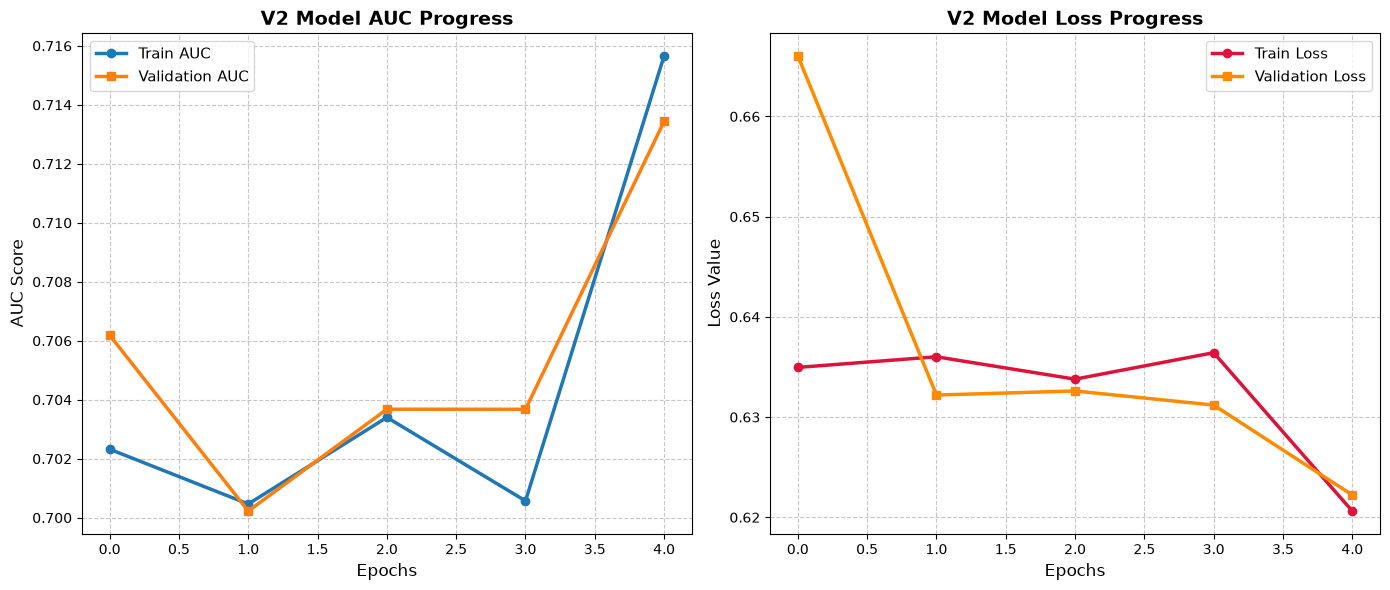

Training performance charts successfully generated and saved as 'v2_training_performance.png'.


In [5]:
import matplotlib.pyplot as plt

# Set the overall figure size for high-resolution layout
plt.figure(figsize=(14, 6))

# 1. Plot AUC Metric (Training vs Validation)
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC', linewidth=2.5, marker='o')
plt.plot(history.history['val_auc'], label='Validation AUC', linewidth=2.5, marker='s')
plt.title('V2 Model AUC Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Plot Loss Metric (Training vs Validation)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2.5, marker='o', color='crimson')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, marker='s', color='darkorange')
plt.title('V2 Model Loss Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout and save the high-quality plot for presentation slides
plt.tight_layout()
plt.savefig('v2_training_performance.png', dpi=300)
plt.show()

print("Training performance charts successfully generated and saved as 'v2_training_performance.png'.")